In [14]:
import numpy as np
import matplotlib.pyplot as plt
import re
import random
from scipy.stats import loguniform

# For plotting contours
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

import os

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.rc = {'figure.figsize': (6, 4)}

In [15]:
samples = loguniform.rvs(1e-4, 1e-1, size=1000)
print(samples.min(), samples.max(), np.median(samples))

0.00010017608911343252 0.09997773350106787 0.0031241867189910387


In [16]:
from src.load_data import load_ishigaki, load_hw2002, load_ishigaki_selected, load_takahashi, load_ww95, load_limongi18

from src.utils import _isotope_to_element, _isotope_label, _combine_elements, extract_yield_peaks
from params import filter_elements, f_star_by_f_dil

from src.plot import plot_yields, plot_one_yield

from src.salvadori_funcs import salvadori_Zism, salvadori_abundance_ratio, salvadori_H_ratio, salvadori_combined_abundratio,salvadori_combined_abundratio_WrtH
from src.salvadori_funcs import salvadori_yields as salvadori_yields_convert
from src.formulas import abundance_ratio


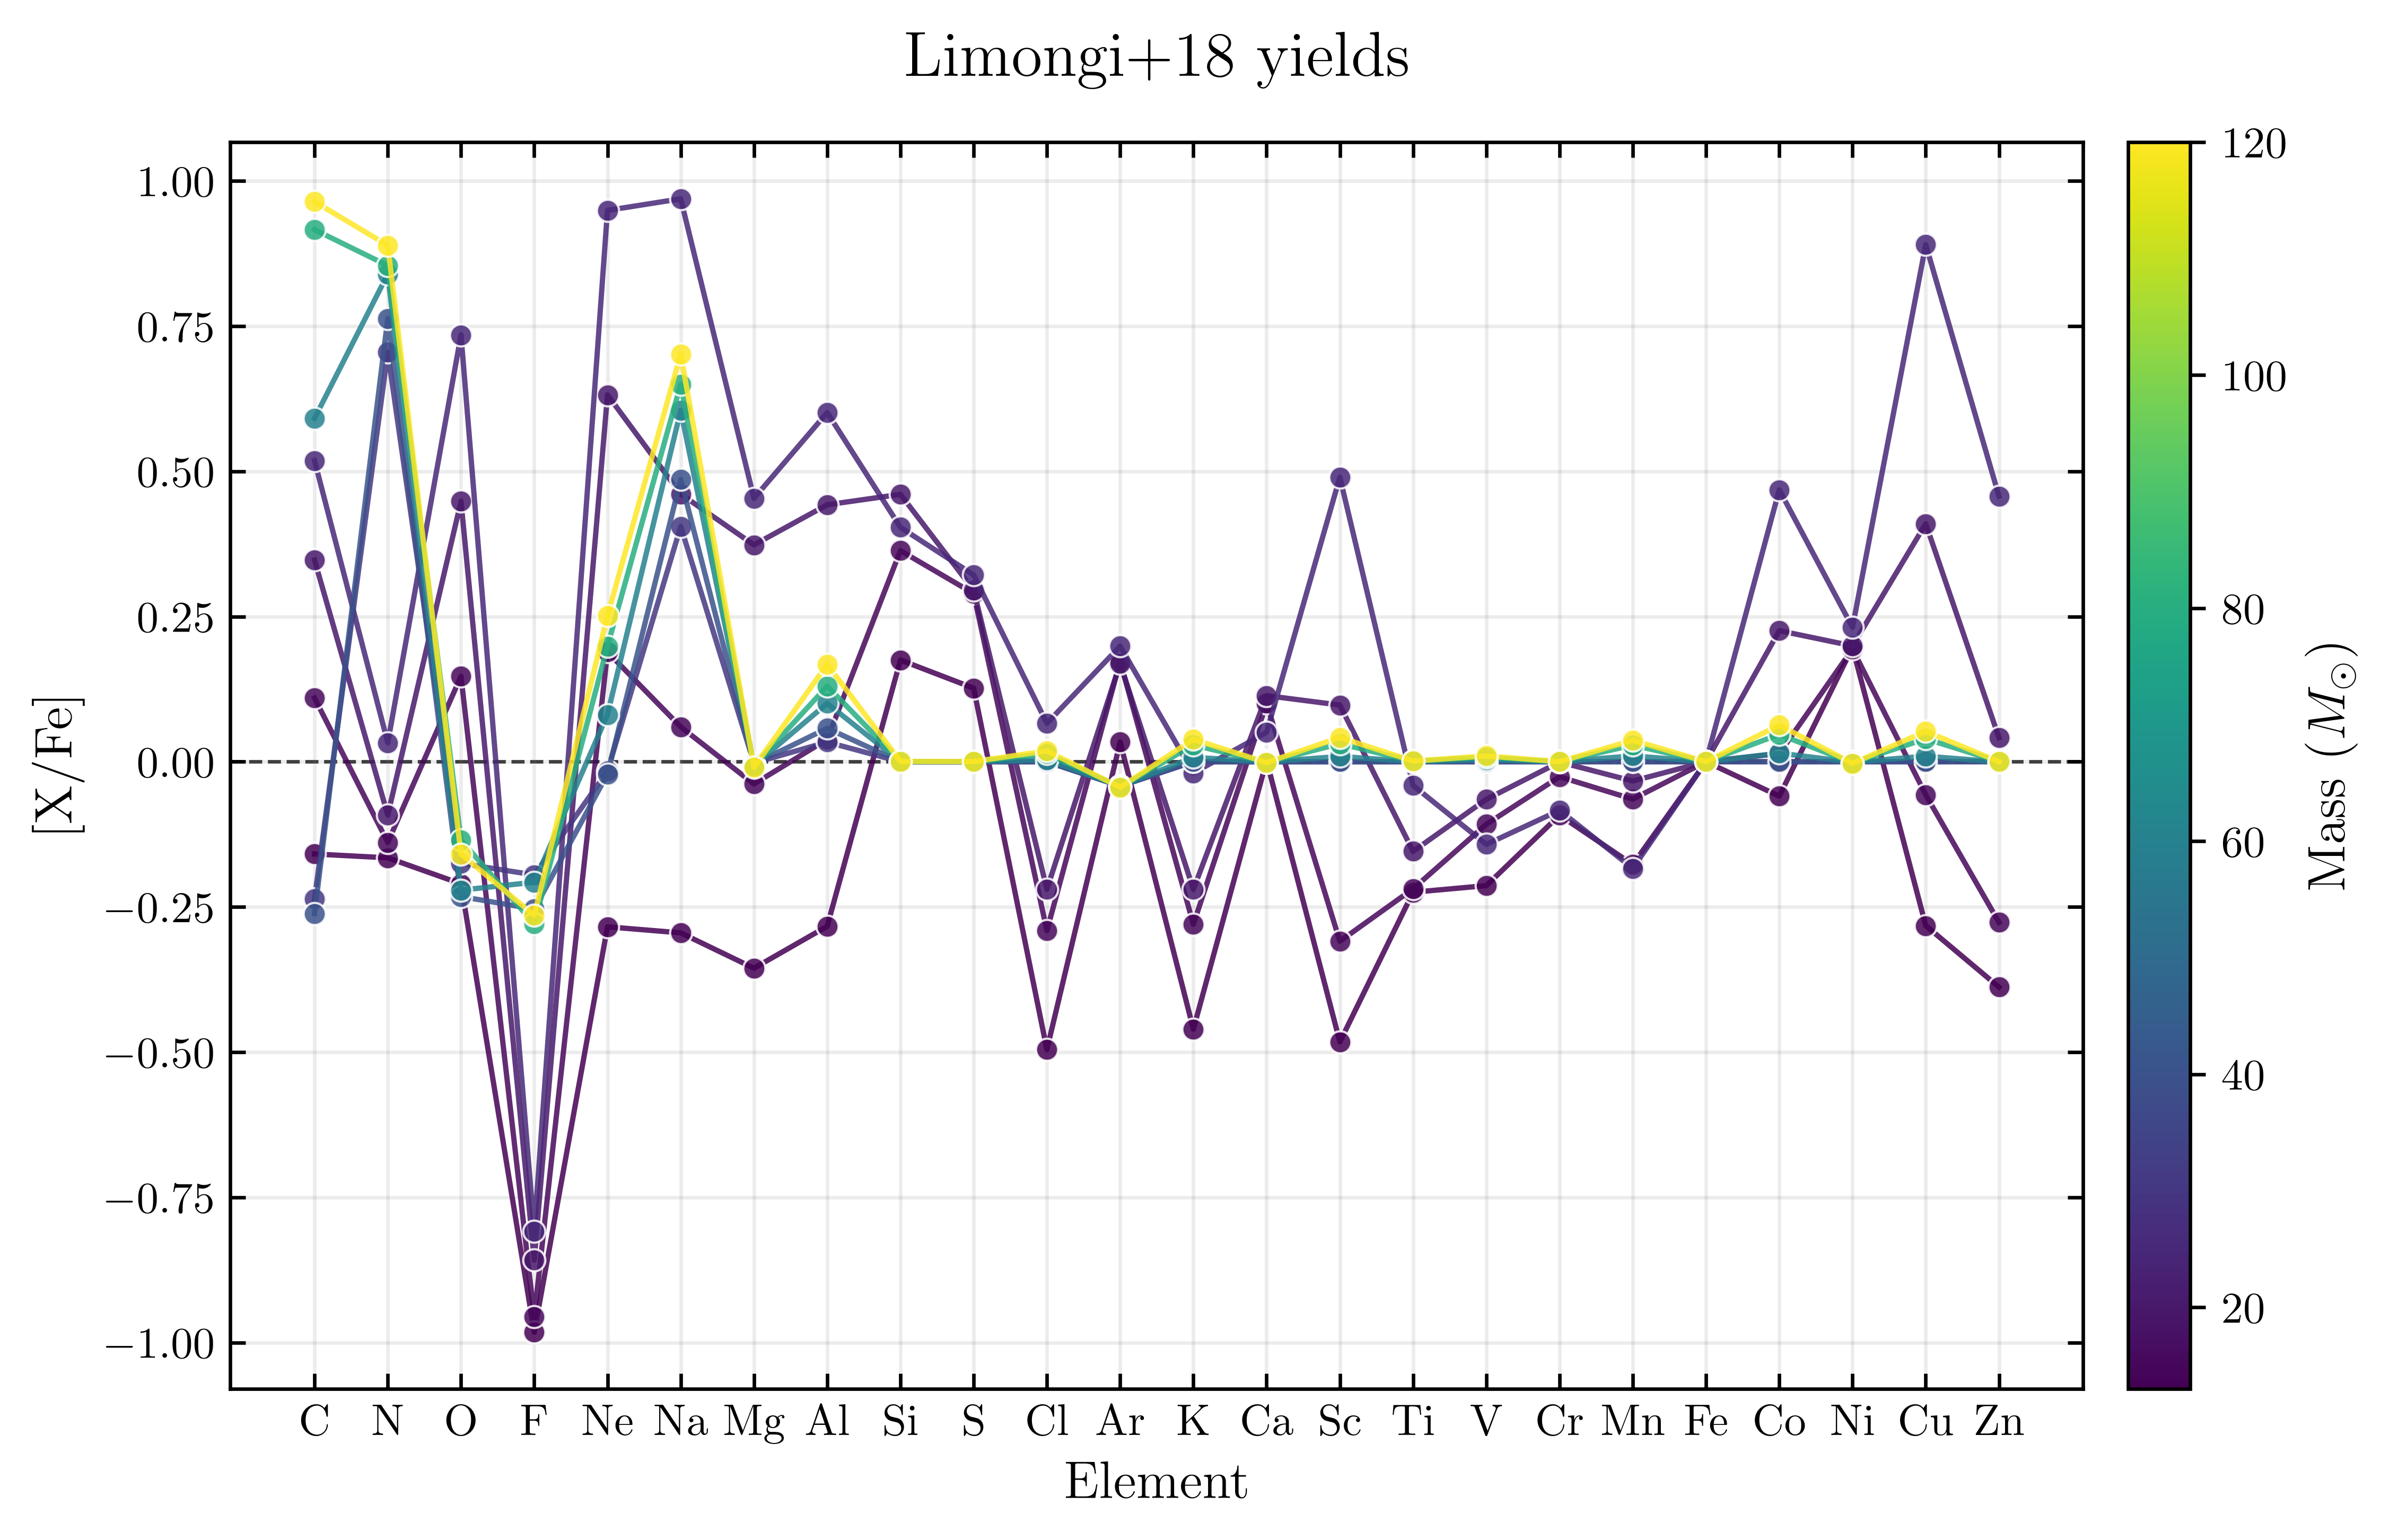

<Axes: title={'center': 'Limongi+18 yields'}, xlabel='Element', ylabel='[$\\mathrm{X} / \\mathrm{Fe}$]'>

In [21]:
limongi18 = load_limongi18()

limongi18 = [e for e in limongi18 if e['params']['velocity'] == 0 and e['params']['feh'] == 0]

plot_yields(limongi18 , filter_elements=filter_elements, title="Limongi+18 yields") 

In [17]:
ishigaki18_yields = load_ishigaki()
hw_yields = load_hw2002()
ishigaki18_selected_yields = load_ishigaki_selected() # NOTE: already summed isotopes
takahashi_yields = load_takahashi()
takahashi_yields = takahashi_yields["NR"] # NOTE: only use non-rotating models for now
ww95_yields = load_ww95()
 

In [ ]:
# ishigaki18_selected_yields = [entry for entry in ishigaki18_selected_yields if entry["params"]["mass"] in [25, 40]]
# ishigaki18_selected_yields[0]

In [18]:
hw_yields = hw_yields[1:]

# for entry in hw_yields:
#     entry['yields'] = _combine_elements(entry['yields'])

In [ ]:
salvadori_yields = salvadori_yields_convert(hw_yields)

for entry in salvadori_yields:
    entry['yields'] = _combine_elements(entry['yields'])

In [ ]:
pisn_yields = hw_yields
sn_yields = limongi18

/tmp/ipykernel_382935/3599924032.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


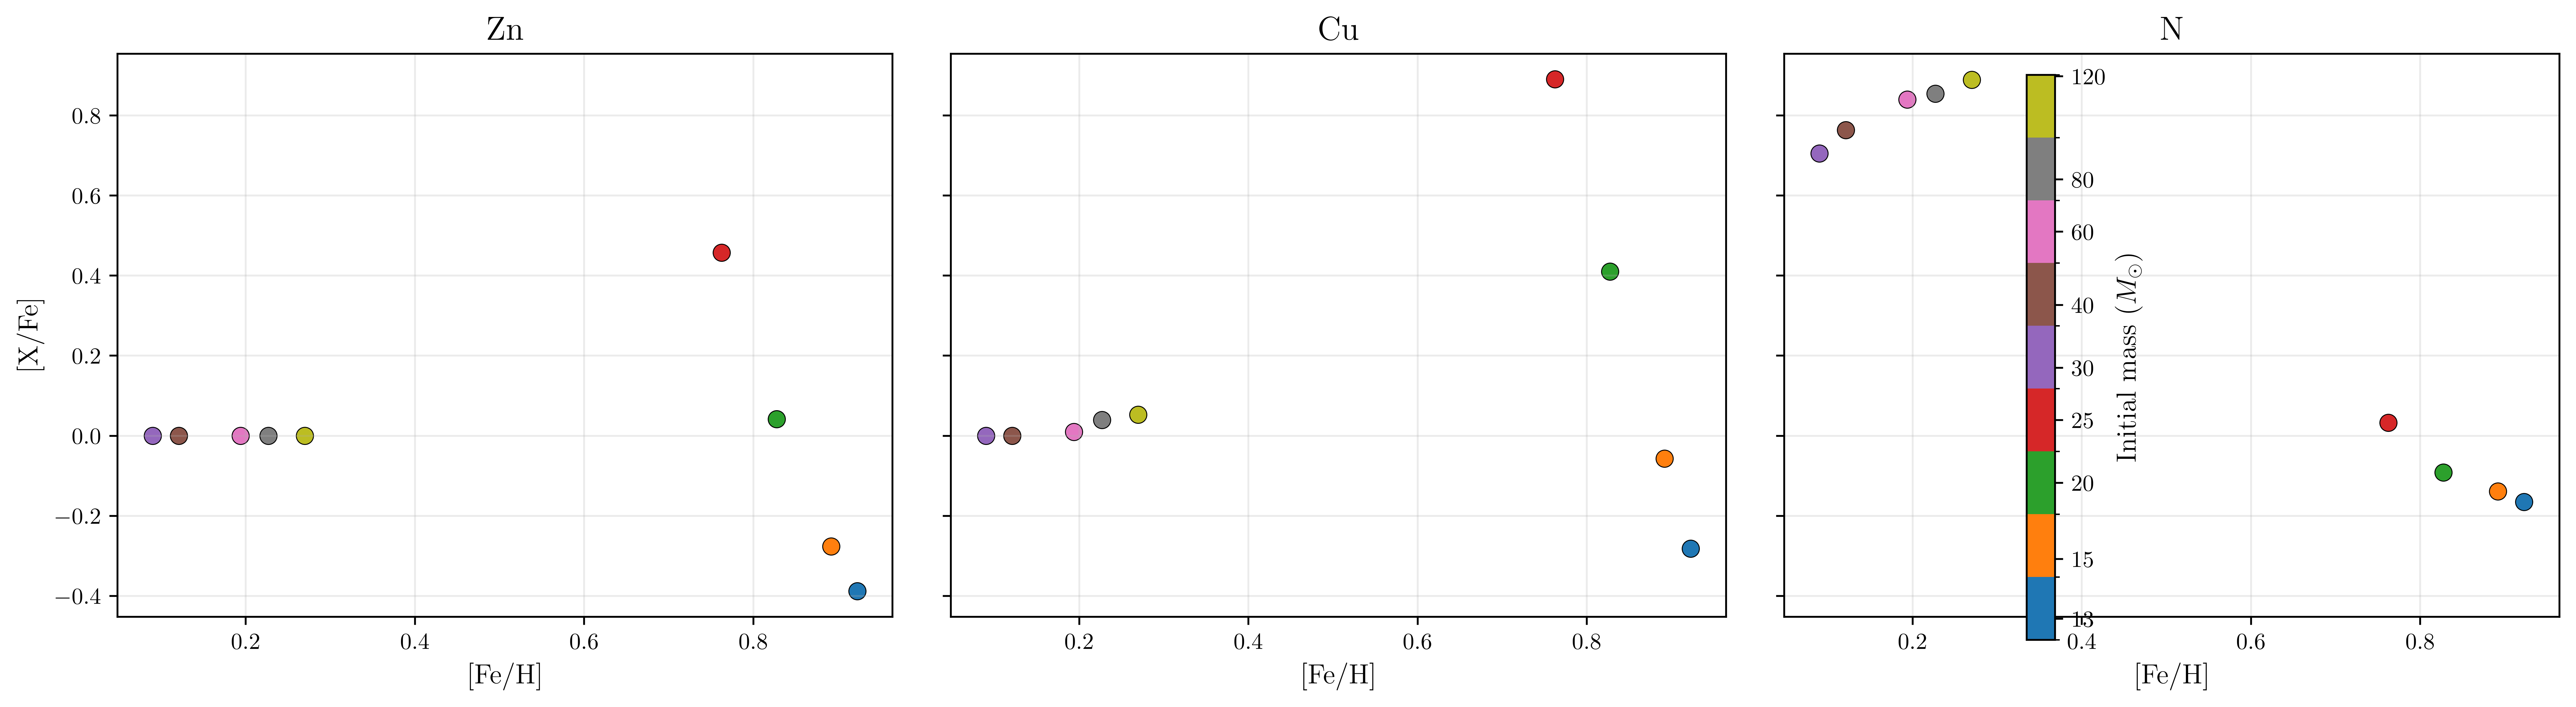

In [25]:
limongi_v0 = [e for e in limongi18 if e["params"]["velocity"] == 0]
from matplotlib.colors import BoundaryNorm, ListedColormap


def plot_xfe_vs_feh(limongi_data, elems=("Zn", "Cu", "N")):
    """Scatter [X/Fe] vs [Fe/H], colored by initial mass, one panel per element.

    Each initial mass gets its own categorical color (not a continuous ramp),
    so uneven mass spacing is unambiguous.
    """
    masses = sorted({e["params"]["mass"] for e in limongi_data})
    n = len(masses)

    # one distinct color per mass, in sorted order
    base = plt.get_cmap("tab10")  # 10 qualitative colors
    colors = [base(i % 10) for i in range(n)]
    cmap = ListedColormap(colors)

    # boundaries halfway between consecutive masses; extend ends outward
    bounds = [masses[0] - 0.5] + [(masses[i] + masses[i + 1]) / 2 for i in range(n - 1)] + [masses[-1] + 0.5]
    norm = BoundaryNorm(bounds, cmap.N)

    mass_to_color = {m: colors[i] for i, m in enumerate(masses)}

    fig, axes = plt.subplots(
        1, len(elems), figsize=(5.2 * len(elems), 4.4), sharey=True
    )
    if len(elems) == 1:
        axes = [axes]

    for ax, elem in zip(axes, elems):
        for e in limongi_data:
            y = e["yields"]
            y_Fe = y.get("Fe", 0.0)
            y_H = y.get("H", 0.0)
            y_elem = y.get(elem, 0.0)
            if y_H <= 0 or y_Fe <= 0:
                continue

            feh = abundance_ratio("Fe", "H", y_Fe, y_H)
            xfe = abundance_ratio(elem, "Fe", y_elem, y_Fe)

            ax.scatter(
                feh, xfe,
                s=55,
                facecolor=mass_to_color[e["params"]["mass"]],
                edgecolor="black",
                linewidths=0.4,
            )

        ax.set_title(elem)
        ax.set_xlabel("[Fe/H]")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("[X/Fe]")

    # colorbar with a tick centered on each mass -> distinct labeled color
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, ticks=masses)
    cbar.set_label("Initial mass ($M_\\odot$)")
    cbar.ax.set_yticklabels([str(int(m)) for m in masses])

    fig.tight_layout()
    return fig


fig = plot_xfe_vs_feh(limongi_v0)
fig.savefig("plots/limongi_xfe_vs_feh.png", dpi=300)

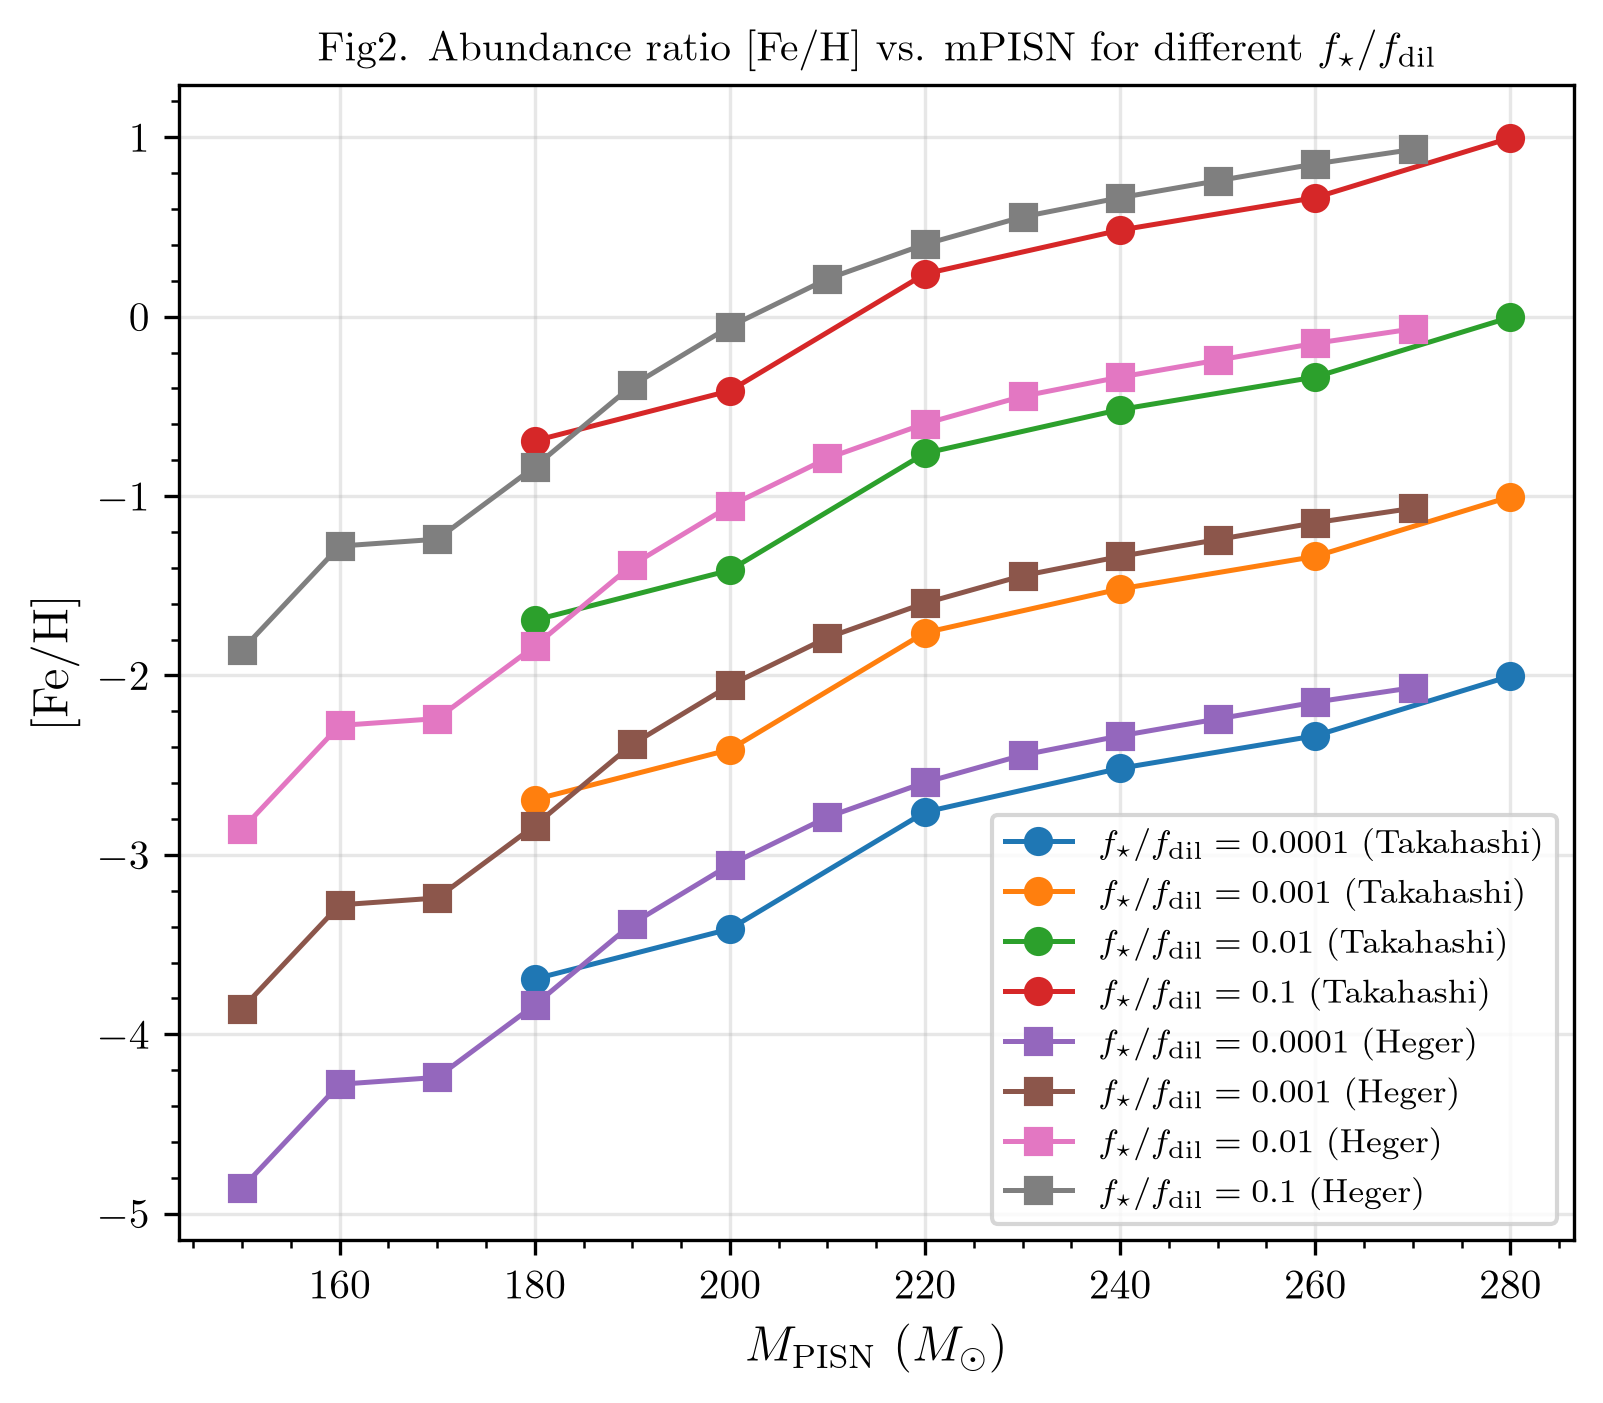

In [ ]:
# salvadori_yields = salvadori_yields_convert(takashi_yields)

sal_tk_yields = salvadori_yields_convert(takahashi_yields)
sal_hw_yields = salvadori_yields_convert(hw_yields)

fig2_values_tk = []
fig2_values_hw = []

for f_ratio in [1e-4, 1e-3, 1e-2, 1e-1]:
    Fe_H_to_mPISN = []

    for y in sal_tk_yields:
        mass = y["params"]["mass"]
        Fe_H = salvadori_H_ratio("Fe", f_ratio, y)
        Fe_H_to_mPISN.append((mass, Fe_H))

    fig2_values_tk.append((f_ratio, Fe_H_to_mPISN))

for f_ratio in [1e-4, 1e-3, 1e-2, 1e-1]:
    Fe_H_to_mPISN = []

    for y in sal_hw_yields:
        mass = y["params"]["mass"]
        Fe_H = salvadori_H_ratio("Fe", f_ratio, y)
        Fe_H_to_mPISN.append((mass, Fe_H))

    fig2_values_hw.append((f_ratio, Fe_H_to_mPISN))

fig, ax = plt.subplots(figsize=(6, 5))

for f_ratio, Fe_H_to_mPISN in fig2_values_tk:
    masses = np.array([m for m, _ in Fe_H_to_mPISN])
    fe_h = np.array([r for _, r in Fe_H_to_mPISN])
    ax.plot(masses, fe_h, marker="o", linewidth=1.2,
            label=rf"$f_\star/f_\mathrm{{dil}} = {f_ratio:g}$ (Takahashi)")
    

for f_ratio, Fe_H_to_mPISN in fig2_values_hw:
    masses = np.array([m for m, _ in Fe_H_to_mPISN])
    fe_h = np.array([r for _, r in Fe_H_to_mPISN])
    ax.plot(masses, fe_h, marker="s", linewidth=1.2,
            label=rf"$f_\star/f_\mathrm{{dil}} = {f_ratio:g}$ (Heger)")

ax.set_xlabel(r"$M_\mathrm{PISN}\ (M_\odot)$")
ax.set_ylabel(r"$[\mathrm{Fe}/\mathrm{H}]$")
ax.legend(fontsize=8)
fig.set_size_inches(6, 5)
ax.grid(True, alpha=0.3)
plt.minorticks_on()
plt.title(r"Fig2. Abundance ratio $[\mathrm{Fe}/\mathrm{H}]$ vs. mPISN for different $f_\star/f_\mathrm{dil}$", fontsize=10)
plt.show()


4 peaks found
{'pisn': {'mass': 240}, 'sn': {'mass': 15.0, 'lfej': -3.0, 'energy': 1.0, 'elem_value': 5.0498e-09, 'Fe_value': 9.0305e-05}, 'ratios': {'C': np.float64(-0.9426966548069489), 'N': np.float64(-0.05807492995229735), 'O': np.float64(-0.0784756800380132), 'F': np.float64(-4.195938151523944), 'Ne': np.float64(-0.5296968765041663), 'Na': np.float64(-1.3214191644309703), 'Mg': np.float64(-0.35252164724729906), 'Al': np.float64(-1.4781606089100947), 'Si': np.float64(0.5193715874506325), 'S': np.float64(0.7310601218952746), 'Cl': np.float64(-1.2299729496164304), 'Ar': np.float64(0.6983658745835514), 'K': np.float64(-0.9174268202004795), 'Ca': np.float64(0.8170185430636554), 'Sc': np.float64(-1.4487874238953946), 'Ti': np.float64(-0.1440684071947178), 'V': np.float64(-0.7555515659171784), 'Cr': np.float64(0.3365918183503765), 'Mn': np.float64(-0.41020964492649425), 'Fe': np.float64(0.0), 'Co': np.float64(-1.4235924758020968), 'Ni': np.float64(-0.7417775819100045), 'Cu': np.float64(-

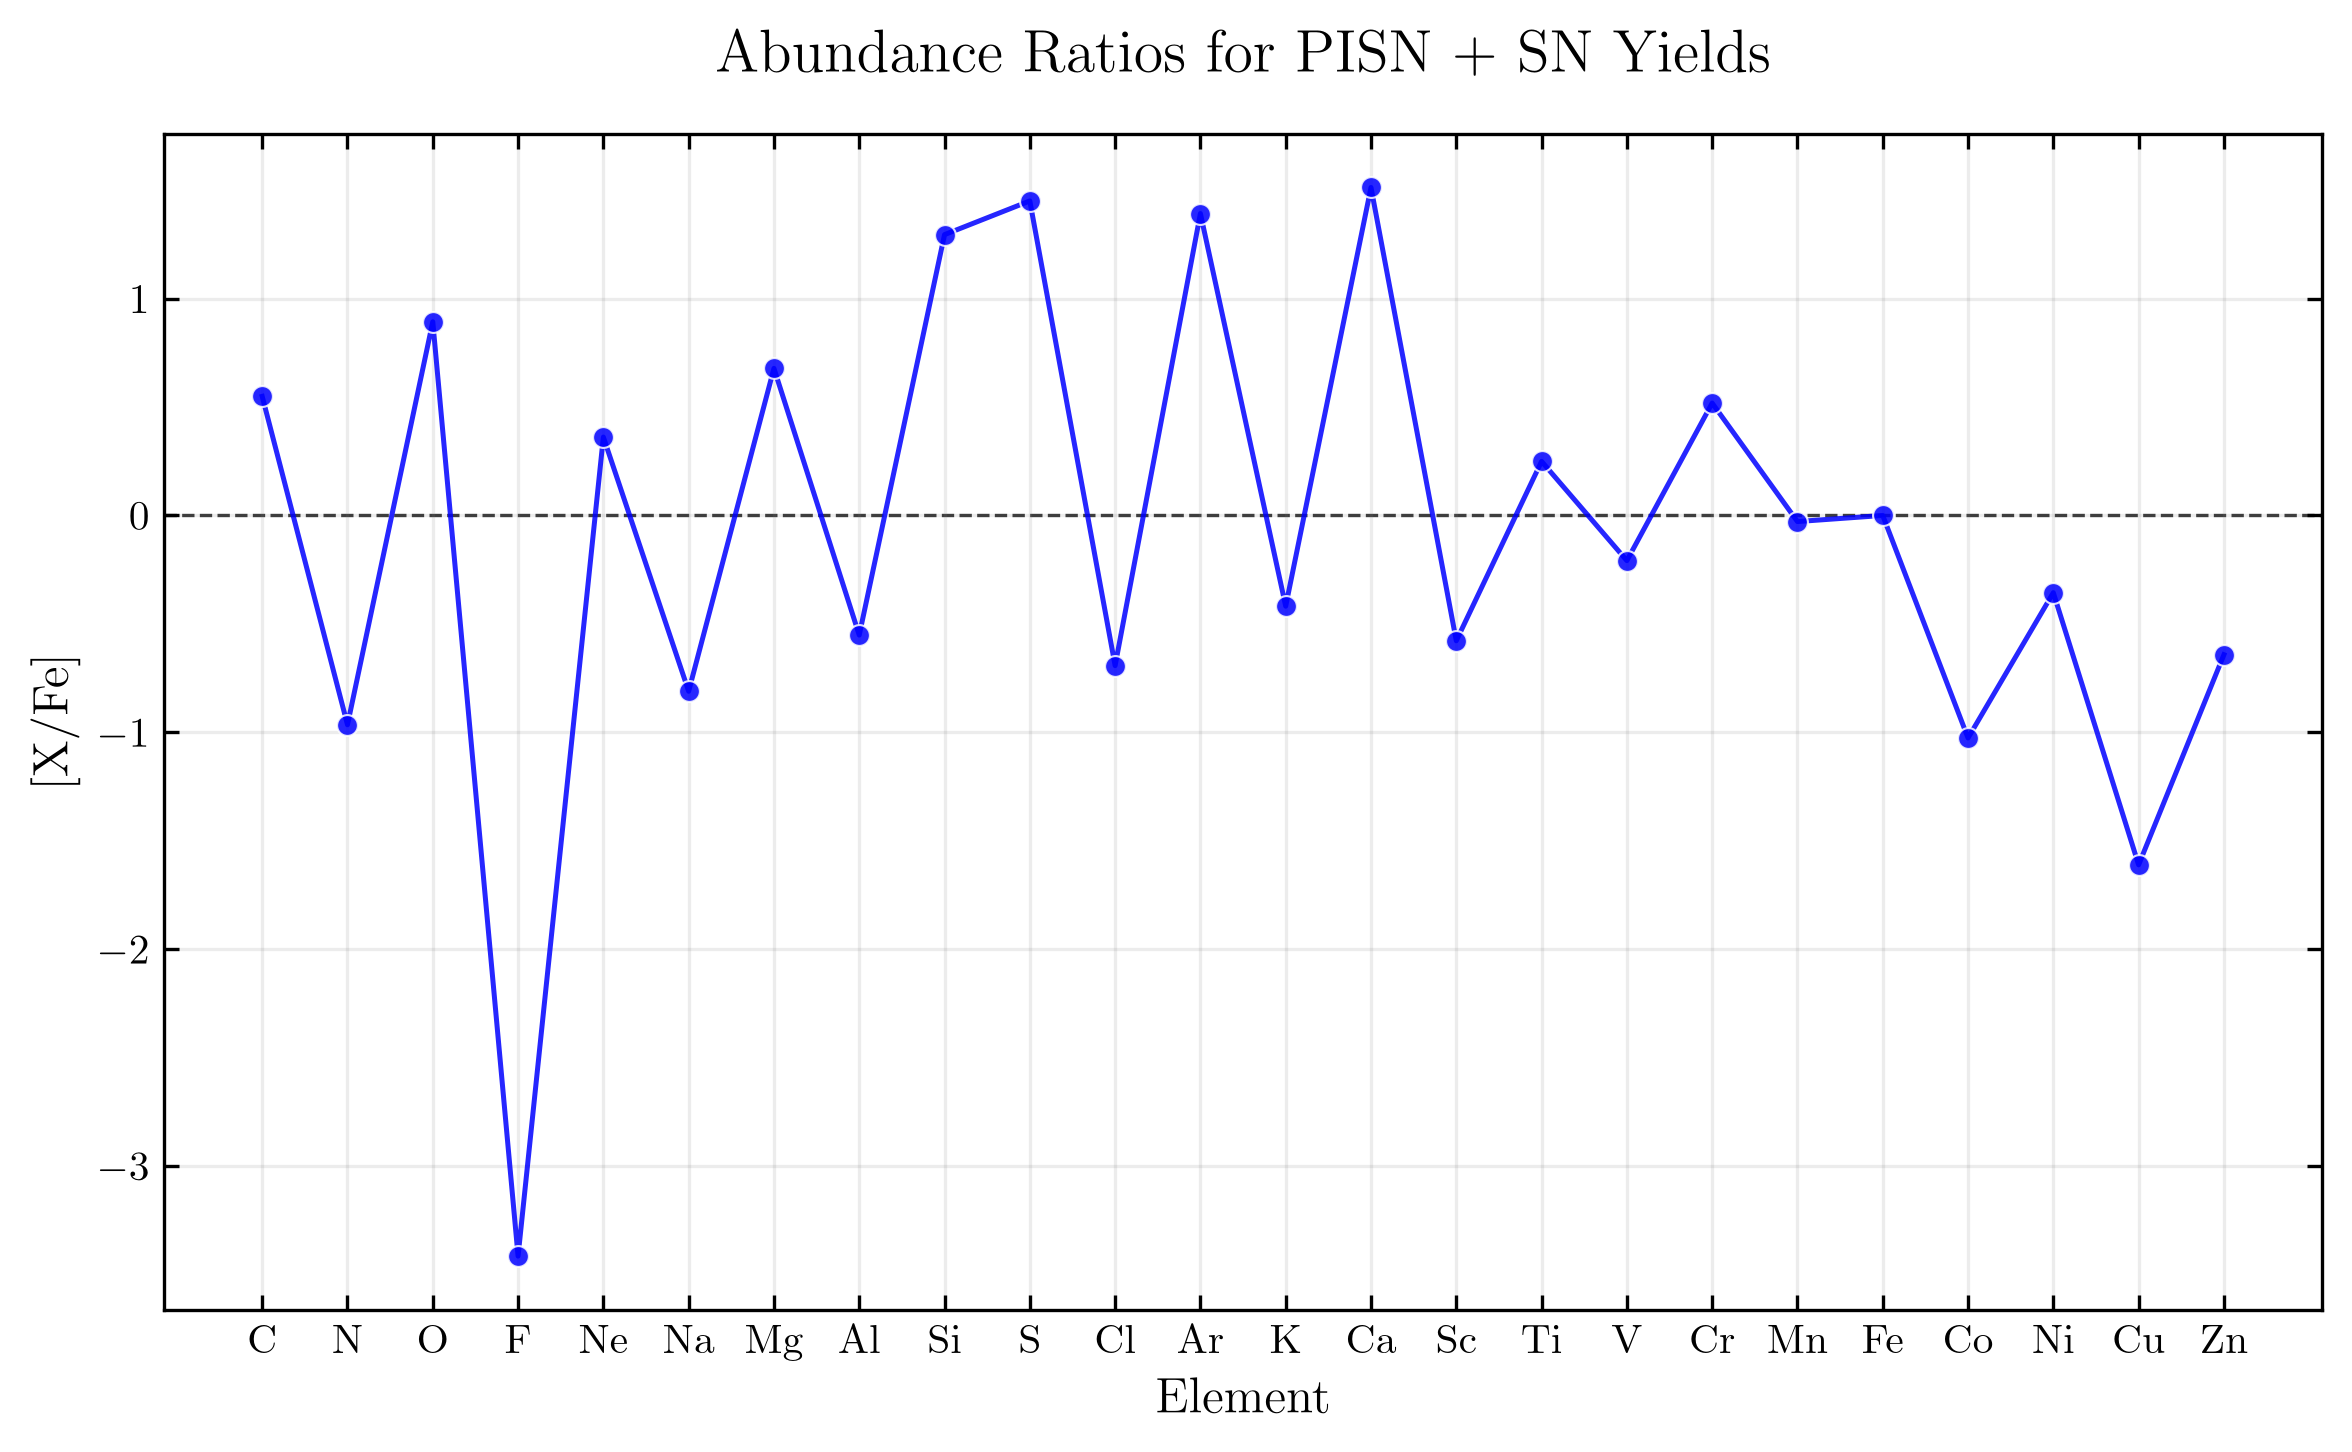

In [ ]:
X_fe_values = {}

pisn_entry = random.choice(pisn_yields)
sn_entry = random.choice(sn_yields)

f_pisn = 0.5

# for elem in filter_elements:
#     X_Fe_yield = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_entry, sn_entry, f_pisn=f_pisn)
#     X_fe_values[elem] = X_Fe_yield

# plot_one_yield(X_fe_values, title="Abundance Ratios for Random PISN and SN Yields", filter_elements=filter_elements)

peak_yield = extract_yield_peaks(pisn_yields, sn_yields, elem="Cu",f_pisn=0.9,f_ratio=1e-3,n_samples=1000)
print(len(peak_yield), "peaks found")
print(peak_yield[0])

plot_one_yield(peak_yield[1]["ratios"], title="Abundance Ratios for PISN + SN Yields", filter_elements=filter_elements)

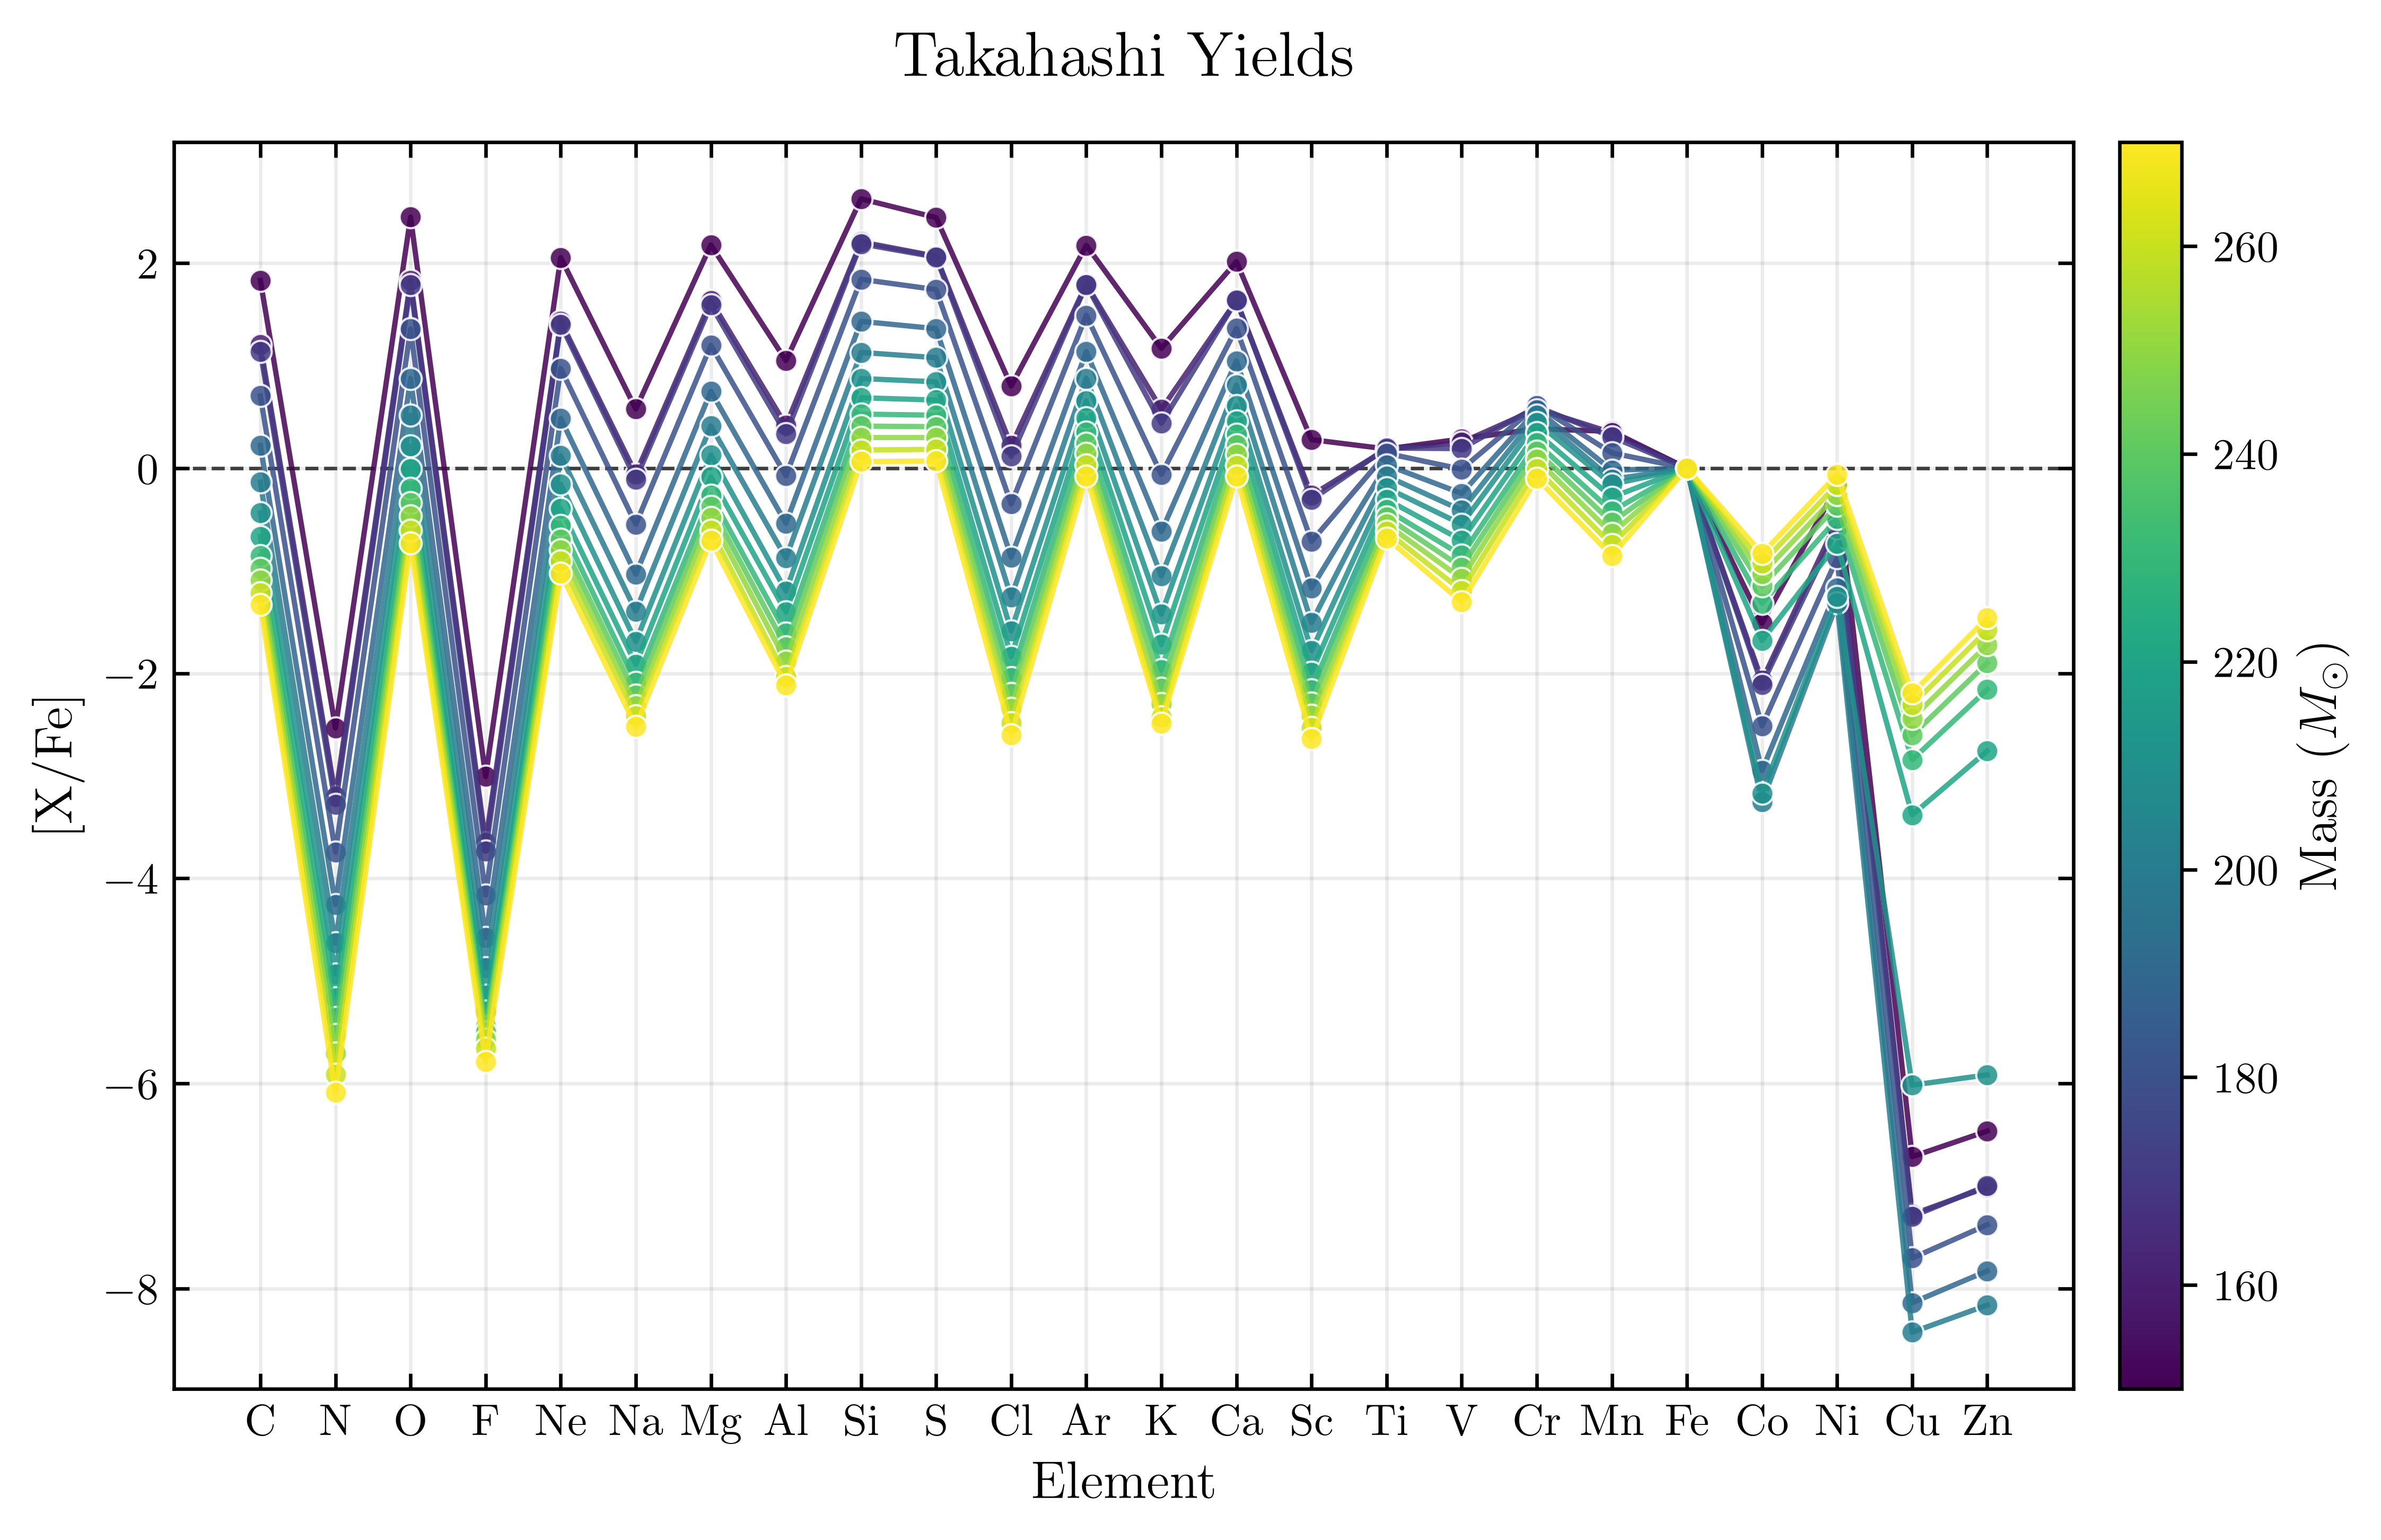

<Axes: title={'center': 'Takahashi Yields'}, xlabel='Element', ylabel='[$\\mathrm{X} / \\mathrm{Fe}$]'>

In [19]:
plot_yields(hw_yields, title="Takahashi Yields", combine_elements=True, filter_elements=filter_elements)

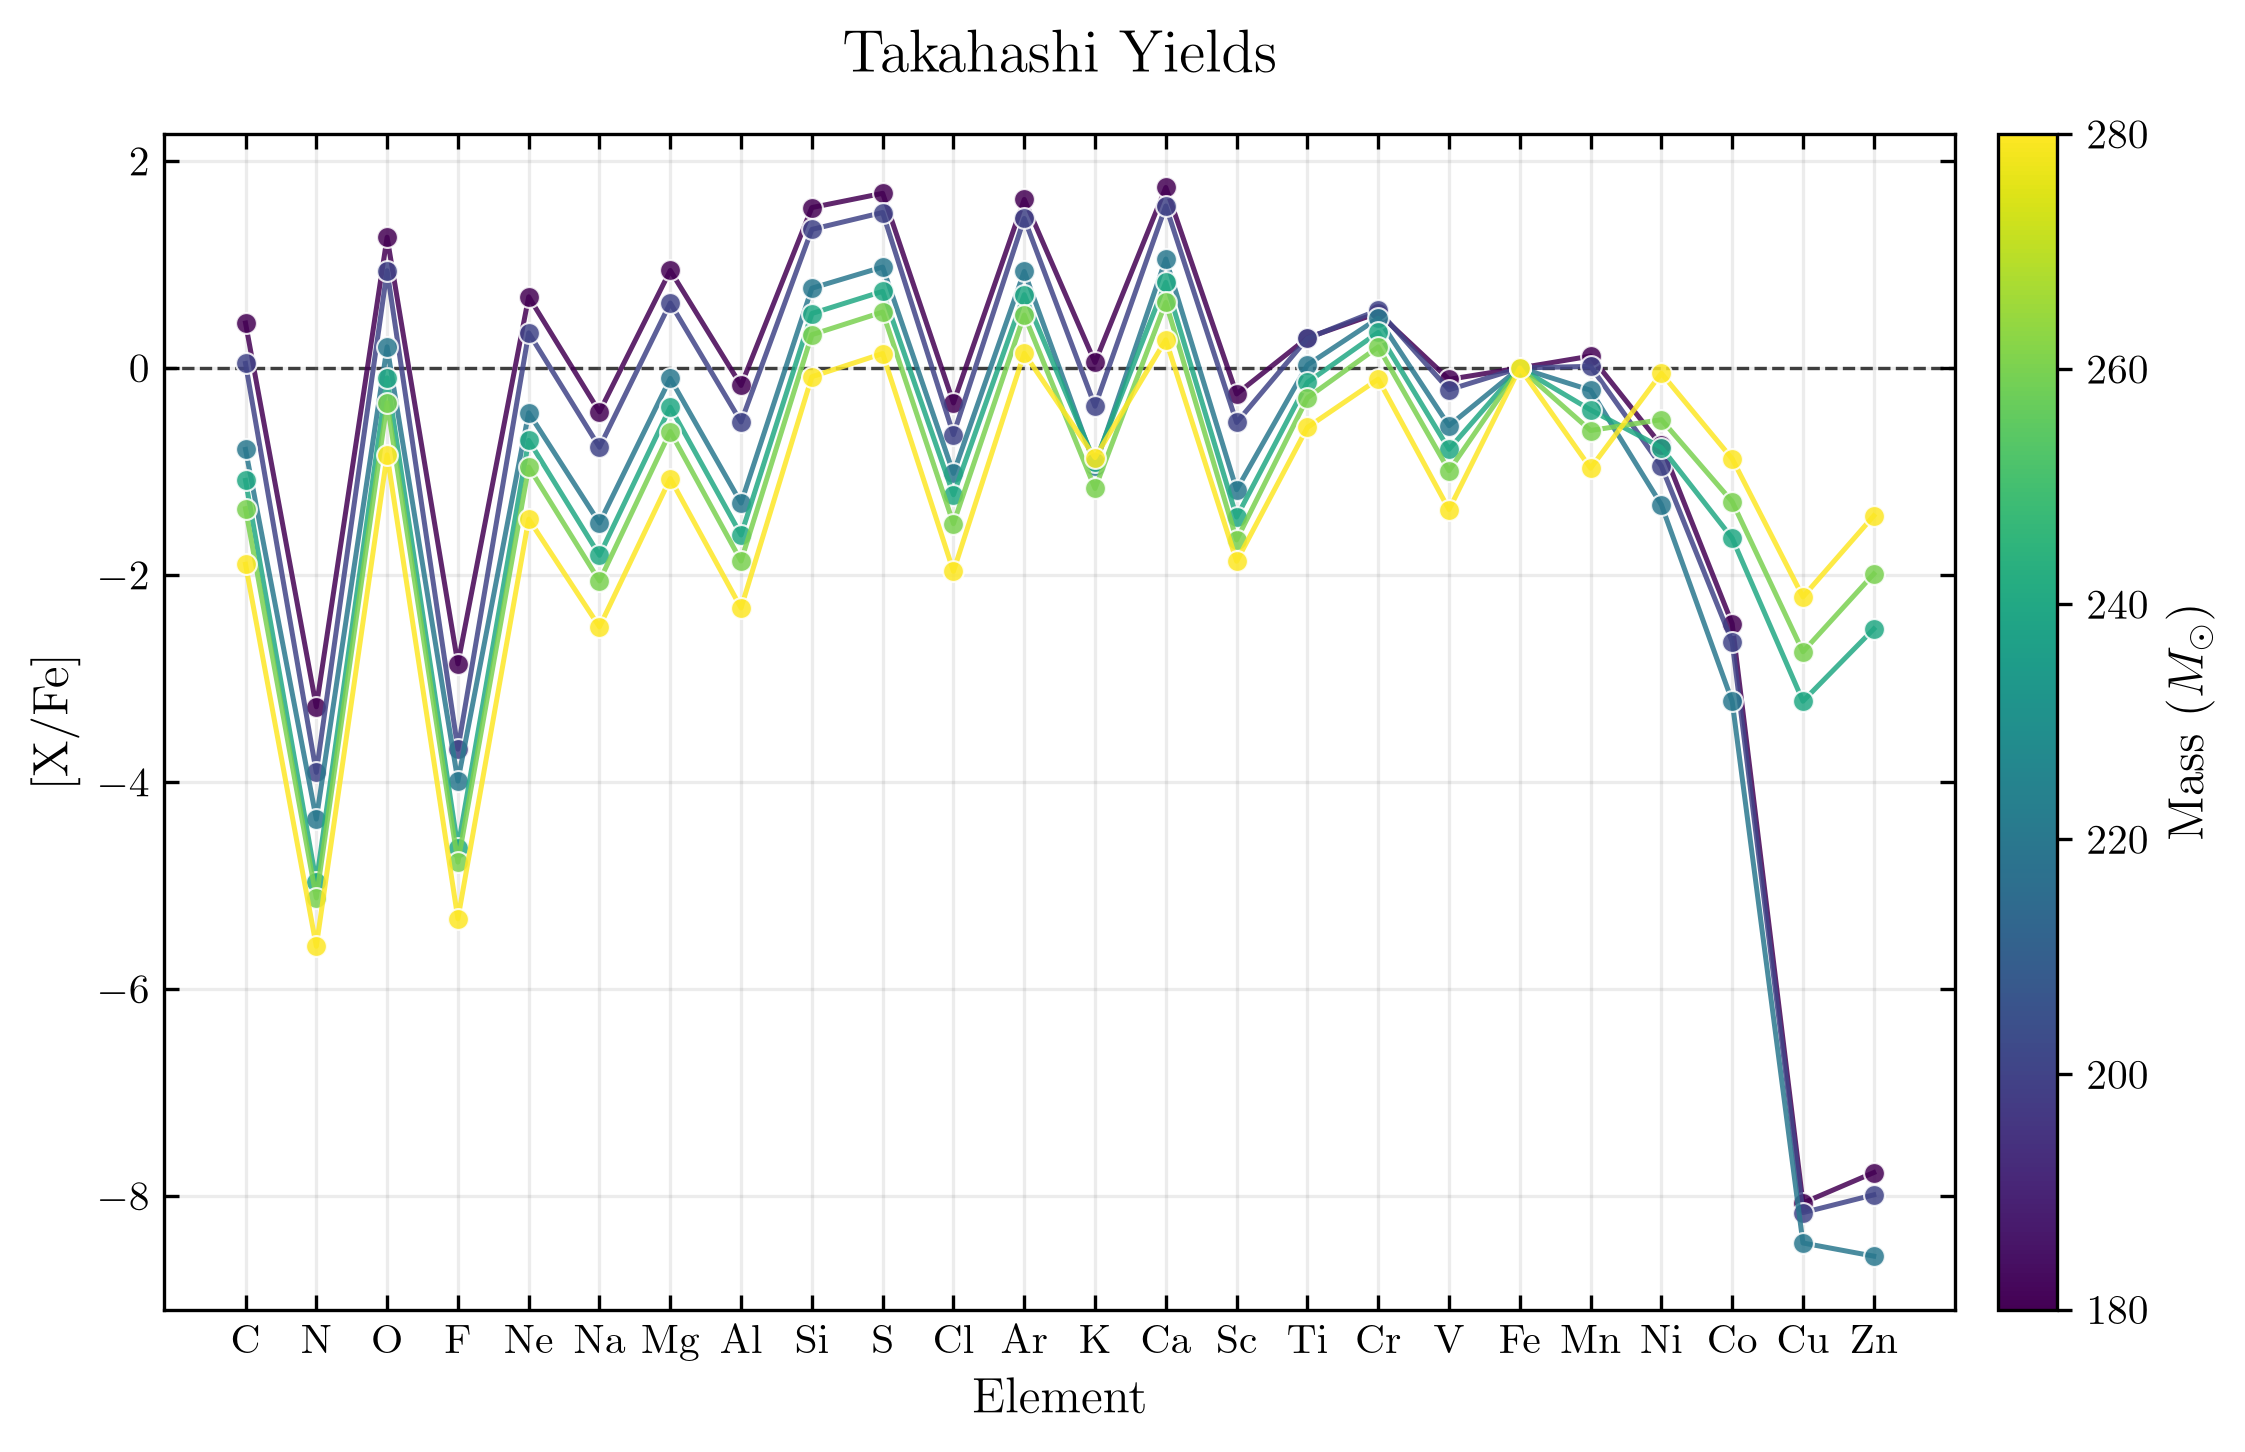

In [ ]:
plot_yields(takahashi_yields, title="Takahashi Yields", combine_elements=True, filter_elements=filter_elements)

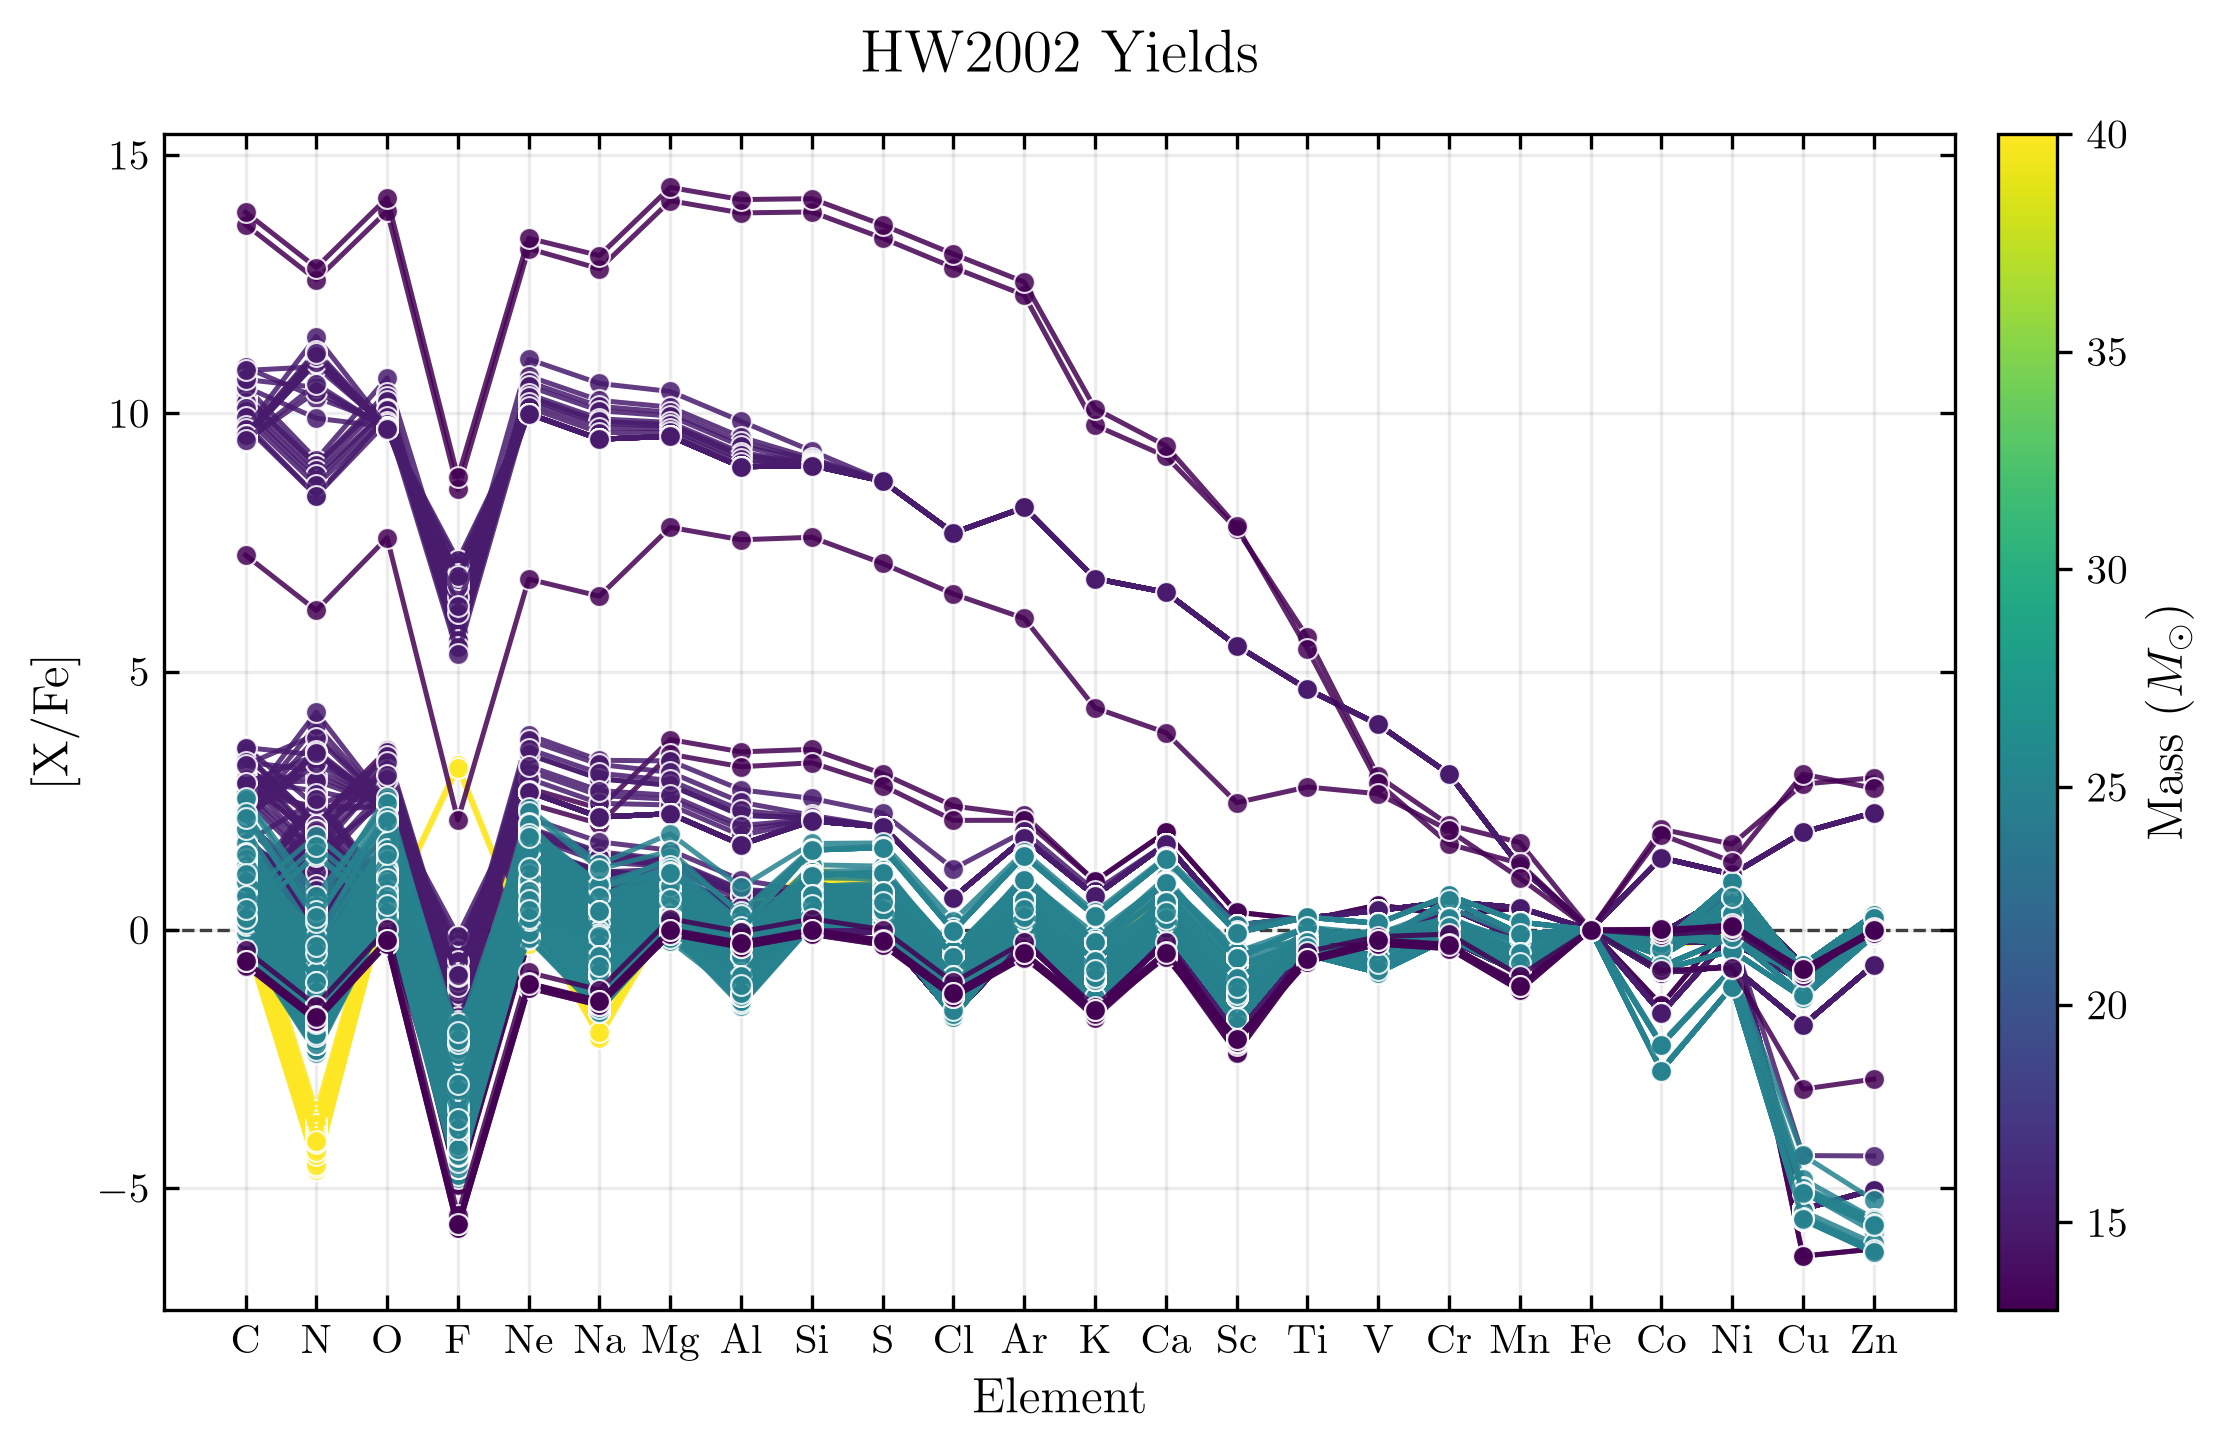

In [ ]:
plot_yields(ishigaki18_selected_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)

In [ ]:
# plot_yields(ishigaki_yields, title="Ishigaki 2018 Yields", combine_elements=True, filter_elements=filter_elements)